<a href="https://colab.research.google.com/github/soumilimahindar-Asure/Machine-Learning/blob/main/AIML_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost

First 5 rows:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Dataset Shape:
(418, 12)

Original Column Names:
['PassengerId', 'Survi

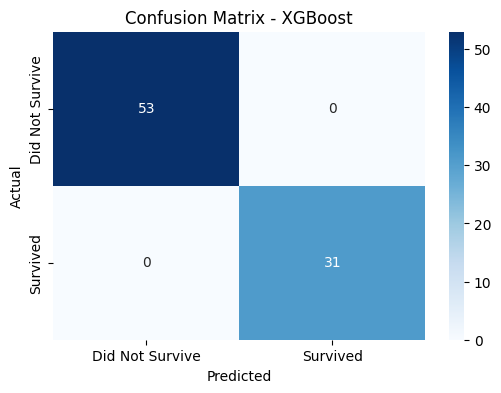


Classification Metrics
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       1.00      1.00      1.00        53
       Survived       1.00      1.00      1.00        31

       accuracy                           1.00        84
      macro avg       1.00      1.00      1.00        84
   weighted avg       1.00      1.00      1.00        84


ROC-AUC Score
ROC-AUC: 1.0


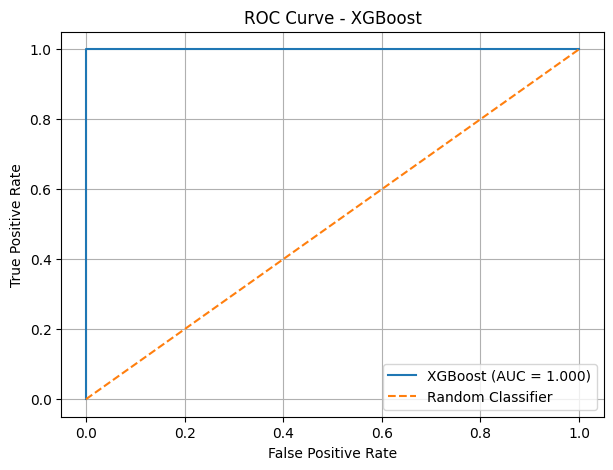


Feature Importance
      Feature  Importance
5    Sex_male    0.778966
3       Parch    0.052553
4        Fare    0.040816
6  Embarked_Q    0.034901
0      Pclass    0.032169
1         Age    0.021157
7  Embarked_S    0.020415
2       SibSp    0.019024


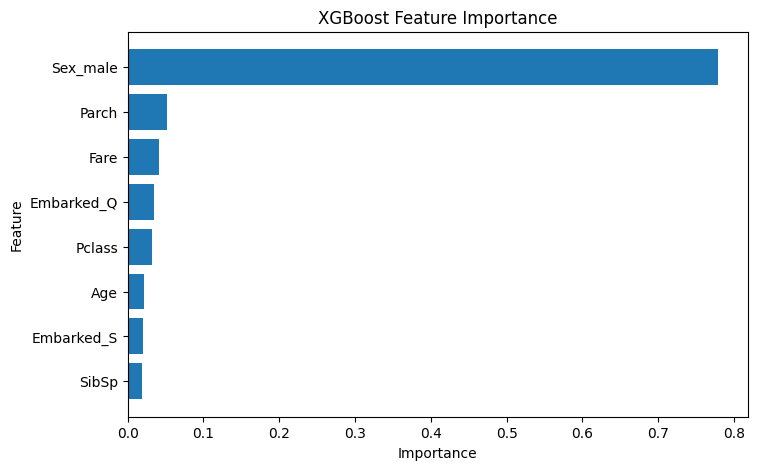


FINAL MODEL PERFORMANCE
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000
ROC-AUC   : 1.0000

Most Important Features:
Sex_male : 0.7790
Parch : 0.0526
Fare : 0.0408
Embarked_Q : 0.0349
Pclass : 0.0322


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier
df = pd.read_csv("Titanic-Dataset.csv")
print("First 5 rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nOriginal Column Names:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())
print("\nZero Values:")
print((df == 0).sum())
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features].copy()
y = df["Survived"]
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])
print("\nMissing values after treatment:")
print(X.isnull().sum())
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

print("\nFeatures after encoding:")
print(X.head())
print("\nFinal feature names:")
print(X.columns.tolist())
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeature scaling completed.")
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train_scaled, y_train)
print("\nXGBoost model training completed.")
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
print("\n==============================")
print("Accuracy")
print("==============================")
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
cm = confusion_matrix(y_test, y_pred)
print("\n==============================")
print("Confusion Matrix")
print("==============================")
print(cm)
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n==============================")
print("Classification Metrics")
print("==============================")

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Did Not Survive", "Survived"]
))
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n==============================")
print("ROC-AUC Score")
print("==============================")
print("ROC-AUC:", roc_auc)
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid()
plt.show()
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n==============================")
print("Feature Importance")
print("==============================")
print(feature_importance)
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()
print("\n========================================")
print("FINAL MODEL PERFORMANCE")
print("========================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nMost Important Features:")

for index, row in feature_importance.head(5).iterrows():
    print(
        f"{row['Feature']} : "
        f"{row['Importance']:.4f}"
    )